In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import h5py

import os
import sys
print(os.getpid())
sys.path.append(os.path.abspath("./"))
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

import pylib.Chebyschev_coefs as ch

import stepanoff

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

14584
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_ = "../QuCF/simulations/Stepanoff/init_mod"
for i in range(100):
    plt.close()

	nx 	6
	nxD 	12

// --- For initialization subcircuit ---
	alpha_init_0 	0.000000000000e+00
	alpha_init_1 	1.595729601823e+00


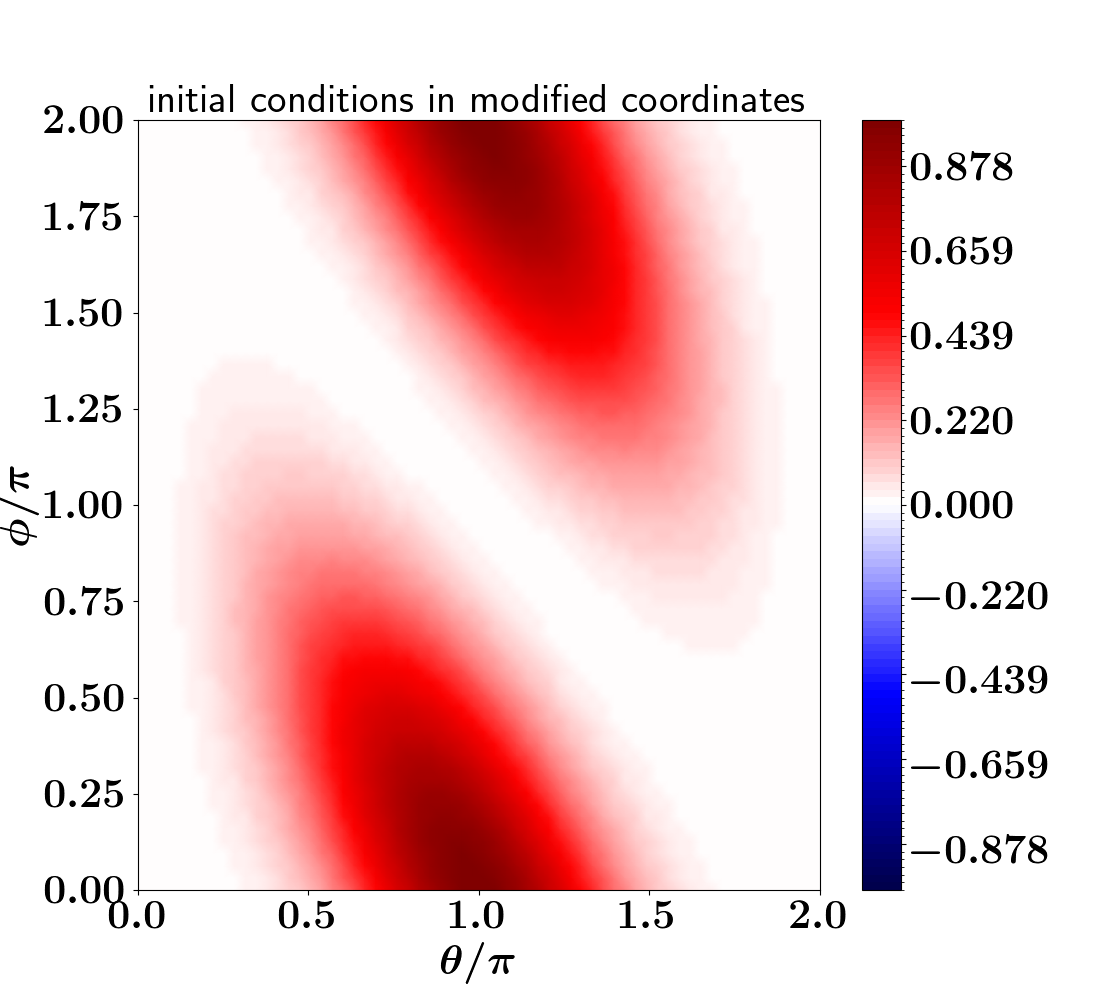

In [8]:
# -----------------------------------------------------
# --- Initial parameters ---
# -----------------------------------------------------
mix.reload_module(stepanoff)
def plot_2D(X, Y, f, str_title="", fontsize = 30,):
    fig = plt.figure(figsize=(11,10))
    ax = fig.add_subplot(111)

    f_max_loc = np.max(np.abs(f))

    cmap = plt.get_cmap("seismic")
    levels = np.linspace(-f_max_loc, f_max_loc, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    cs = ax.pcolormesh(X, Y, f, cmap=cmap, norm=divnorm, shading='gouraud') 
    cb = fig.colorbar(cs, ax = ax)
    cb.ax.ticklabel_format(style="scientific")
    cb.ax.tick_params(labelsize=fontsize)

    offset_text = cb.ax.yaxis.get_offset_text()
    offset_text.set_fontsize(fontsize) 
    offset_text.set_x(4) 

    ax.set_xlabel('$\\theta/\pi$', fontsize = fontsize)
    ax.set_ylabel("$\phi/\pi$", fontsize = fontsize)
    ax.set_title(str_title, fontsize = fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    # ax.grid()
    return
# -----------------------------------------------------
def plot_2D_subplot(
        ax, fig, X, Y, f, 
        str_title="", fontsize = 30, 
        label_x = '$\\theta/\pi$', label_y = "$\phi/\pi$"
):
    f_max_loc = np.max(np.abs(f))

    cmap = plt.get_cmap("seismic")
    levels = np.linspace(-f_max_loc, f_max_loc, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    cs = ax.pcolormesh(X, Y, f, cmap=cmap, norm=divnorm, shading='gouraud') 
    cb = fig.colorbar(cs, ax = ax)
    cb.ax.ticklabel_format(style="scientific")
    cb.ax.tick_params(labelsize=fontsize)

    offset_text = cb.ax.yaxis.get_offset_text()
    offset_text.set_fontsize(fontsize) 
    offset_text.set_x(4) 

    ax.set_xlabel(label_x, fontsize = fontsize)
    ax.set_ylabel(label_y, fontsize = fontsize)
    ax.set_title(str_title, fontsize = fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    # ax.grid()
    return
# -----------------------------------------------------
def plot_init(x):
    Nx = len(x)
    y_2D = stepanoff.f_init_2d(kappa_, x, Nx)

    # --- Plotting 2D ---
    X, Y = np.meshgrid(x/np.pi, x/np.pi)
    plot_2D(X, Y, y_2D, "initial conditions in modified coordinates")
    return
# -----------------------------------------------------
def plot_and_save_sin_full(N):
    x = np.linspace(-np.pi, np.pi, N) 

    f_loc = lambda x1: np.exp(kappa_ * np.sin(x1)**2) - 1
    y = f_loc(x) / f_loc(np.pi/2.)

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x/np.pi, y, color="b", linewidth = 2, linestyle='-')
    plt.xlabel('$\\theta/\pi$')
    plt.ylabel("y")
    plt.grid(True)
    plt.show()

    mix.save_dat_plot_1d_file(path_save_ + "/init_sin_full.dat", x/np.pi, y)
    return
# -----------------------------------------------------
def compute_sin_parameters(N):
    # --- for angle = [0, np.pi] ---
    alpha_0 = 0.
    alpha_1 = np.pi * N/(2.*(N - 1))

    n = int(np.log2(N))
    nD = 2 * n

    print("\tnx \t{:d}".format(n))
    print("\tnxD \t{:d}".format(nD))
    print()
    print("// --- For initialization subcircuit ---")
    print("\talpha_init_0 \t{:0.12e}".format(alpha_0))
    print("\talpha_init_1 \t{:0.12e}".format(alpha_1))
    return
# -----------------------------------------------------
kappa_ = 1.


n_, rr_init_ = 6, 3.216984647198e+00
# n_, rr_init_ = 8, 3.221144236543e+00


N_ = 1 << n_
x_ = np.linspace(0., 2.*np.pi, N_)

compute_sin_parameters(N_)
plot_init(x_)

# plot_and_save_sin_full(N_)

Reading the file ../QuCF/simulations/Stepanoff/init_mod/init_mod_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is init_mod
Simulation has been performed  07-23-2025 19:26:18

qucf_coef_norm: 4.926510394873e-02

-----------------------------------------------------------
N-gates: 2734
max-abs-err: 2.184e-12

A-max (before renorm.): 4.916830075530e-02
success prob. (before renorm.): 9.999085054732e-01


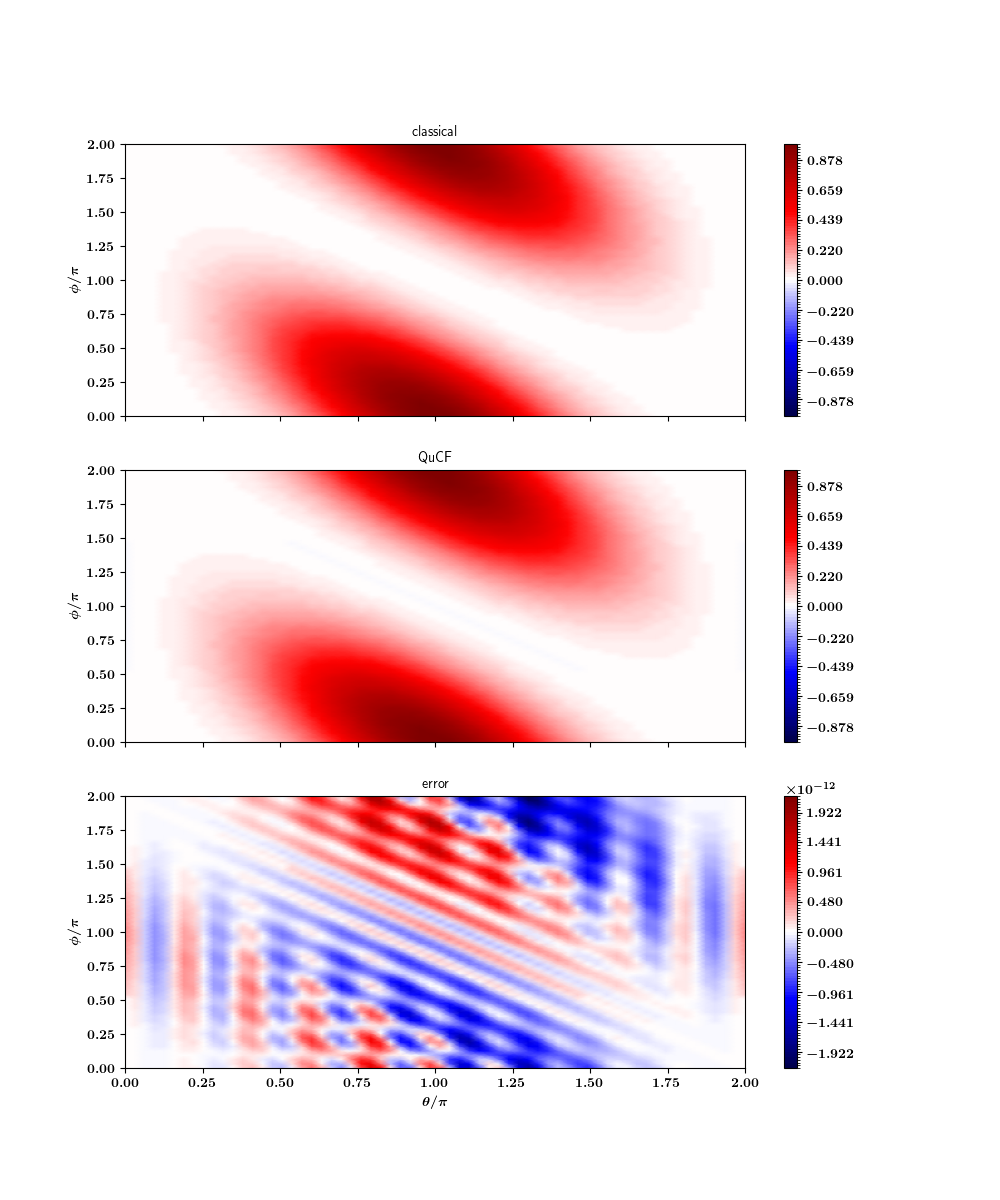

In [ ]:
# -------------------------------------------------------------
# --- Compare QuCF (QSVT) and classical initializations ---
# -------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(mse)
def plot_qucf_initialization_2D(
    flag_plot, 
    flag_AA,       # if the signal is amplified
    flag_norm_max, # normalize to the maximum amplitude 
    flag_plot_1D = False
  ):
    '''
    > When AA is included, keep flag_AA = False, 
      to find the amplitude of the amplified signal to compute rr.
    > Set flag_AA = True, when AA is included in QuCF simulations and 
      when rr has already been found.
    '''

    # --- reading QuCF simulations ---
    om = mse.MeasOracle__()
    om.path_  = path_qucf_
    om.pname_ = "init_mod"
    om.open()

    # --- The total number of gates in the circuit ---
    Ngates = om.dd_["N-gates"]

    # --- spatial grid ---
    nx = int(om.constants_["nx"])
    Nx = 1 << nx
    x = np.linspace(0, 2.*np.pi, Nx)

    # --- rescaling factors ---
    om.read_qsvt()
    resc_qsvt = om.dd_["init"]["rescaling_factor"]

    Hadamart_norm_factor = 2.**(nx//2)
    resc_coef = (Hadamart_norm_factor / resc_qsvt)**2
    if flag_AA:
        resc_coef *= 1. / rr_init_

    # --- QuCF signal ---
    om.set_zero_ancillae_work_states(0)
    f_qucf = om.get_var_x({}, "r")

    succ_prob = np.sum(np.abs(f_qucf)**2)
    max_ampl = np.max(np.abs(f_qucf))

    f_qucf = f_qucf.real
    f_qucf_2D = np.zeros((Nx, Nx))
    for i_phi in range(Nx):
      for i_theta in range(Nx):
        f_qucf_2D[i_theta, i_phi] = f_qucf[i_theta + Nx * i_phi]

    # --- Normalization of the QuCF signal ---
    if flag_norm_max:
      f_qucf_2D /= max_ampl
      print("\nqucf_coef_norm: {:0.12e}".format(max_ampl))
    else:
      f_qucf_2D *= resc_coef
      print("\nqucf_coef_norm: {:0.12e}".format(1./resc_coef))

    # --- Plotting 1D format of the 2D data ---
    if flag_plot_1D:
      fig, ax = plt.subplots()
      ax.plot(range(Nx*Nx), f_qucf, "-r", label = "QuCF") 
      ax.set_xlabel('x')
      ax.set_ylabel("y")
      ax.grid()
      ax.legend()

    # --- Classical data ---
    f_cl_2D = stepanoff.f_init_2d(kappa_, x, Nx) 
    if flag_norm_max:
      f_cl_2D /= np.max(np.abs(f_cl_2D))  # due to the discretization the max is not exactly one
    
    # --- Errors ---
    err_abs_2D = f_cl_2D - f_qucf_2D
    max_err = np.max(np.abs(err_abs_2D))

    # --- Printing data ---
    print("\n-----------------------------------------------------------")
    print("N-gates: {:d}".format(Ngates))
    print("max-abs-err: {:0.3e}".format(max_err))
    print("\nA-max (before renorm.): {:0.12e}".format(max_ampl))
    print("success prob. (before renorm.): {:0.12e}".format(succ_prob))

    # --- Plotting ---
    if flag_plot:
        # X, Y = np.meshgrid(x/np.pi, x/np.pi)
        # plot_2D(X, Y, f_cl_2D, "classical")
        # # plot_2D(X, Y, f_qucf_2D, "QuCF")
        # plot_2D(X, Y, err_abs_2D, "error in the encoded initial conditions")

        X, Y = np.meshgrid(x_/np.pi, x_/np.pi)

        # fig1, axs = plt.subplots(3, 1, figsize=(10,18))
        # fontsize = 30

        fig1, axs = plt.subplots(3, 1, figsize=(10,12))
        fontsize = 10

        stepanoff.plot_2D_subplot(
            axs[0], fig1, X, Y, f_cl_2D,  
            str_title="classical", 
            label_x = '', label_y = "$\phi/\pi$", fontsize = fontsize,
            flag_x = False
        )
        stepanoff.plot_2D_subplot(
            axs[1], fig1, X, Y, f_qucf_2D,  
            str_title="QuCF", 
            label_x = '', label_y = "$\phi/\pi$", fontsize = fontsize, 
            flag_x = False,
        )
        stepanoff.plot_2D_subplot(
            axs[2], fig1, X, Y, err_abs_2D,   
            str_title="error", 
            label_x = '$\\theta/\pi$', label_y = "$\phi/\pi$", fontsize = fontsize,
            flag_x = True
        )
    return 
# -----------------------------------------------------
flag_plot = True

flag_AA = True

flag_norm_max = False 

plot_qucf_initialization_2D(flag_plot, flag_AA, flag_norm_max)
del flag_plot, flag_AA

In [7]:
# ----------------------------------------------------------
# --- Amplitude amplification ---
# ----------------------------------------------------------
def print_rr(line_str, A_ampl, A_non_ampl):
    rr = A_ampl / A_non_ampl
    print("{:s}:\t rr = {:0.12e}".format(line_str, rr))
    return
# ---------------------------------------
# *** Here, succ_prob is a non-amplified success probability. ***
def print_NA(line_str, succ_prob):
    theta_AA = np.arcsin(np.sqrt(succ_prob))
    N_AA = int(0.5 * (np.pi/(2.*theta_AA) - 1.))  # +/- 1
    print("{:s}:\t N_AA {:d}".format(line_str, N_AA))
    return
# ---------------------------------------
def compute_AA_init():
    # --- Compute the ration between amplified and non-amplified signals ---
    print_rr("kappa = 1.0,  n = 6", 4.916830075530e-02, 1.528397121762e-02)
    print_rr("kappa = 1.0,  n = 8", 1.233072055739e-02, 3.828056011122e-03)

    # --- Compute the number of repetitions of the AA operator: +/- 1 ---
    print()
    print_NA("kappa = 1.0,  n = 6", 9.661894389566e-02)
    print_NA("kappa = 1.0,  n = 8", 9.639595374381e-02)
    return
# ---------------------------------------
compute_AA_init()

kappa = 1.0,  n = 6:	 rr = 3.216984647198e+00
kappa = 1.0,  n = 8:	 rr = 3.221144236543e+00

kappa = 1.0,  n = 6:	 N_AA 1
kappa = 1.0,  n = 8:	 N_AA 1


In [ ]:
# ----------------------------------------------------------------------------------
# --- Compare QuCF (QSVT) and classical FOURIER TRANSFORM of the initializations ---
# ----------------------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(mse)
def plot_qucf_init_FOURIER(flag_fourier_theta):
    def rearrange_fourier_elements(fft_2d_init):
        fft_signal = np.zeros((Nx, Nx), dtype=complex)

        fft_signal = np.fft.fftshift(fft_2d_init, axes=id_axis)

        # if flag_fourier_theta: # Fourier over theta
        #     for i_phi in range(Nx):
        #         y_fft = np.array(fft_2d_init[:, i_phi])
        #         y_fft = np.concatenate( (y_fft[Nx//2:Nx], y_fft[0:Nx//2]) )
        #         fft_signal[:, i_phi] = y_fft
        # else:
        #     for i_theta in range(Nx):
        #         y_fft = np.array(fft_2d_init[i_theta, :])
        #         y_fft = np.concatenate( (y_fft[Nx//2:Nx], y_fft[0:Nx//2]) )
        #         fft_signal[i_theta, :] = y_fft

        max_ampl = np.max(np.abs(fft_signal))
        fft_signal /= max_ampl
        return fft_signal
    # ---------------------------------------------------------
    id_axis = 1 - int(flag_fourier_theta)

    # --- reading QuCF simulations ---
    om = mse.MeasOracle__()
    om.path_  = path_qucf_
    om.pname_ = "init_mod"
    om.open()

    # --- spatial grid ---
    nx = int(om.constants_["nx"])
    Nx = 1 << nx
    x = np.linspace(0, 2.*np.pi, Nx)

    # --- Fourier grid ---
    coef_ff = 2.*np.pi
    dx = np.diff(x)[0]
    dk = coef_ff / (dx*Nx)
    k_array_pos = np.linspace(              0, coef_ff/(2*dx) - dk, Nx//2) 
    k_array_neg = np.linspace(-coef_ff/(2*dx),                 -dk, Nx//2)
    k_array = np.concatenate((k_array_neg, k_array_pos))

    # -------------------------------------
    # --- QuCF signal ---
    om.set_zero_ancillae_work_states(0)
    f_qucf = om.get_var_x({}, "r")

    f_qucf_2D = np.zeros((Nx, Nx))
    for i_phi in range(Nx):
       for i_theta in range(Nx):
          f_qucf_2D[i_theta, i_phi] = f_qucf[i_theta + Nx * i_phi]
    fft_qucf = rearrange_fourier_elements(f_qucf_2D)

    # -------------------------------------
    # --- classical Fourier ---
    f_cl = stepanoff.f_init_2d(kappa_, x, Nx) 
    fft_cl = np.fft.fft(f_cl, axis=id_axis)
    fft_cl = rearrange_fourier_elements(fft_cl)

    # # -------------------------------------
    # # --- 1D plot ---
    # for ii in range(-2,3):
    #     fig = plt.figure()
    #     ax = fig.add_subplot(111)
    #     if flag_fourier_theta:
    #         ax.plot(x, fft_cl[Nx//2 + ii,:], "b", label = "CL") 
    #         ax.plot(x, fft_qucf[Nx//2 + ii, :], "--r", label = "QC") 
    #         plt.xlabel('phi')
    #     else:
    #         ax.plot(x, fft_cl[:, Nx//2 + ii], "b", label = "CL") 
    #         ax.plot(x, fft_qucf[:, Nx//2 + ii], "--r", label = "QC") 
    #         plt.xlabel('theta')
    #     plt.ylabel('FFT')
    #     plt.title('FFT of the Signal')
    #     plt.legend()
    #     plt.grid()
    #     plt.show()
    # del ii

    # -------------------------------------
    # --- Errors ---
    err_abs_2D = fft_cl - fft_qucf
    max_err = np.max(np.abs(err_abs_2D))
    print("max-abs-err: {:0.3e}".format(max_err))

    # -------------------------------------
    # --- Plotting ---    
    if flag_fourier_theta:
        X, Y = np.meshgrid(k_array, x/np.pi)
        label_x, label_y = '$c_{\\theta}$', "$\phi/\pi$"
    else:
        X, Y = np.meshgrid(x/np.pi, k_array)
        label_x, label_y = '$\\theta/\pi$', "$c_{\phi}$"

    fig1, axs = plt.subplots(3, 1, figsize=(10,18))
    plot_2D_subplot(axs[0], fig1, X, Y, fft_cl.real.transpose(),     "CL",    label_x = label_x, label_y = label_y)
    plot_2D_subplot(axs[1], fig1, X, Y, fft_qucf.real.transpose(),   "QC",    label_x = label_x, label_y = label_y)
    plot_2D_subplot(axs[2], fig1, X, Y, err_abs_2D.real.transpose(), "CL-QC", label_x = label_x, label_y = label_y)
    plt.tight_layout()
    return
# -------------------------------------------------------------
plot_qucf_init_FOURIER(flag_fourier_theta = True)

Function parameter:		 1.000e+00
Chosen function, parity:	 exp_x_squ, 0

max. |norm y|: 9.900e-01


Minimization method is used.
Computation status:  1.2626460879780833e-22

Chosen polynomial's degree:	 20
Number of coefficients:		 10
max. abs. error: 5.136e-13


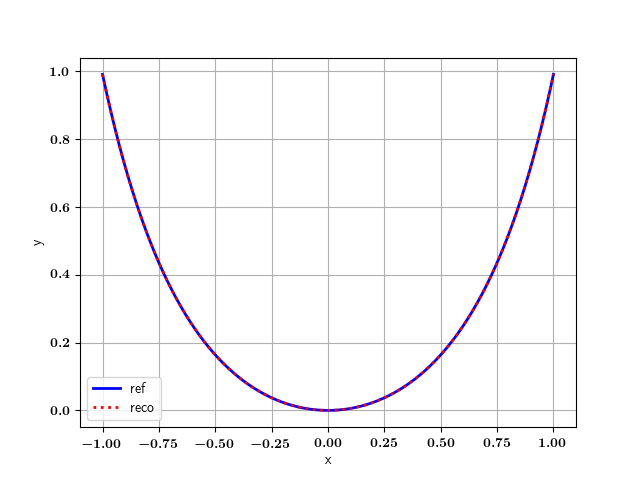

write coefficients to:
 ./tools/QSVT-angles/Stepanoff_Init/coefs//exp_x_squ_1_eps12.hdf5
dir. where angles will be saved:
./tools/QSVT-angles/Stepanoff_Init/
dir. with coefficients:
./tools/QSVT-angles/Stepanoff_Init/coefs
name of the file with coefficients: exp_x_squ_1_eps12.hdf5
name of the file where angles will be saved: angles_exp_x_squ_par1_eps12.hdf5
name of the .ca file used for angle computation: ./tools/QSVT-angles/Stepanoff_Init/calc_exp_x_squ_1_eps12.ca


********************************************************
********************************************************
Project name: ./tools/QSVT-angles/Stepanoff_Init/calc_exp_x_squ_1_eps12

Reading input parameters from the ./tools/QSVT-angles/Stepanoff_Init/calc_exp_x_squ_1_eps12.ca file in the directory:
/media/work/docs/codes/QuCF/scripts-py

	Reading coefficients from the file: ././tools/QSVT-angles/Stepanoff_Init/coefs/exp_x_squ_1_eps12
	The coefficients were computed on: 07/23/2025: 18:59:31
	Done.
herefunction type: 	e

In [56]:
# ------------------------------------------------------------
# --- Computing Chebyschev for initial conditions ---
# ------------------------------------------------------------
mix.reload_module(ch)
def compute_Chebyschev_coefficients(par1, Nd, Nx):
    sel_method = 0
    id_fun = 13

    oo_ch = ch.Ch_()
    oo_ch.choose_method(sel_method)
    oo_ch.choose_func(id_fun, par1)
    oo_ch.compute_Ch(Nd, Nx = Nx)
    oo_ch.plot_reconstructed_function()
    return oo_ch
# -----------------------------------------------------------
def compute_QSVT_angles(oo_ch):
    with h5py.File(oo_ch.full_fname_, "r") as f:
        gr = f["basic"]
        eps_res = np.abs(gr["eps"][()])
    eps_res_log = int(np.round(np.log10(eps_res)))

    filename_angles = "angles_{:s}_par{:s}_eps{:d}".format(oo_ch.line_f_, oo_ch.line_par_, abs(eps_res_log))

    oo_aa = ch.ComputeQSVT_angles_(
        loc_dir_angles = "Stepanoff_Init/",
        filename_coef_without_format = oo_ch.fname_without_format_,
        filename_angles_without_format = filename_angles
    )
    oo_aa.compute_QSVT_angles()
    return
# -----------------------------------------------------------

# --- Compute the coefficients ---
oo_ch_ = compute_Chebyschev_coefficients(
    par1 = kappa_, 
    Nd = 20,
    Nx = 1001
)

# --- Save the coefficients ---
oo_ch_.save_coefficients()

# --- Compute QSVT angles ---
compute_QSVT_angles(oo_ch_)

In [ ]:
N = 4
y_2d = np.arange(N * N).reshape(N, N)

# Convert to 1D using the given indexing
y_1d = y_2d.T.flatten()

print("Original 2D array:")
print(y_2d)

print("\nConverted 1D array:")
print(y_1d)

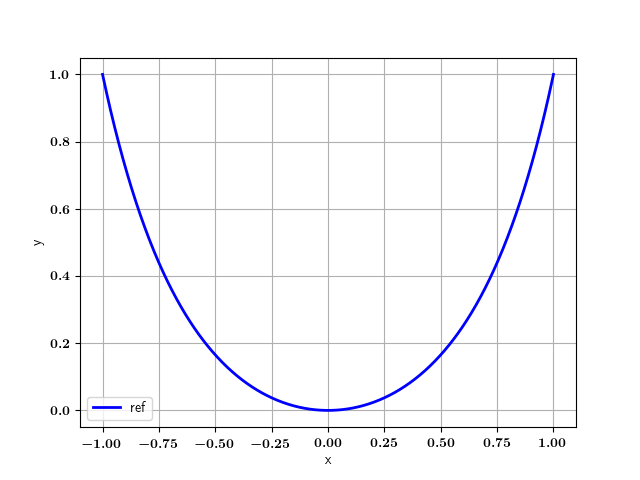

In [23]:
# --------------------------------------------------------------------------------
def test_functions():
    kappa = 1.0

    Nx = 1001
    x = np.linspace(-1., 1., Nx)

    # y = np.exp(kappa * x)
    # y = np.exp(kappa * np.cos(np.pi*x))

    # y = np.sin(np.pi*x)**2
    # y = x**2

    # y = np.exp(kappa * np.sin(np.pi*x)**2) - 1
    # y = np.exp(kappa * x**2) - 1
    # y /= np.max(np.abs(y))

    f_loc = lambda x1: np.exp(kappa * x1**2) - 1.
    y = f_loc(x) / f_loc(1.)

    fig = plt.figure()
    ax = fig.add_subplot(111)

    ax.plot(x, y, color="b", linewidth = 2, linestyle='-', label = "ref")

    plt.xlabel('x')
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()
    return
# --------------------------------------------------------------------------------
def test_Fourier():
    # Sample rate and signal duration
    fs = 1000  # Sampling frequency in Hz
    T = 1.0    # Duration in seconds
    t = np.linspace(0, T, fs, endpoint=False)  # Time vector

    # Create a signal with multiple frequency components
    f1, f2 = 50, 150  # Frequencies in Hz
    signal = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

    # Compute FFT
    N = len(signal)
    fft_values = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(N, d=1/fs)  # Frequency bins

    # Only take the positive half of frequencies (since FFT is symmetric)
    half_N = N // 2


    print(fs)
    print(N)
            
    # --- Plotting ---
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(frequencies[:half_N], np.abs(fft_values[:half_N]) / N)  # Normalize amplitude
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.title('FFT of the Signal')
    plt.grid()
    plt.show()
    return
# ----------------------------------------------------------
test_functions()
# test_Fourier()

In [ ]:
from matplotlib.ticker import MultipleLocator

# --------------------------------------------------------------------------------
def test_Fourier():
    # Sample rate and signal duration
    fs = 1000  # Sampling frequency in Hz
    T = 1.0    # Duration in seconds
    t = np.linspace(0, T, fs, endpoint=False)  # Time vector

    # Create a signal with multiple frequency components
    f1, f2 = 50, 150  # Frequencies in Hz
    signal = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

    # Compute FFT
    N = len(signal)
    fft_values = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(N, d=1/fs)  # Frequency bins

    # Only take the positive half of frequencies (since FFT is symmetric)
    half_N = N // 2

    print(fs)
    print(N)
            
    # --- Plotting ---
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(frequencies[:half_N], np.abs(fft_values[:half_N]) / N)  # Normalize amplitude
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.title('FFT of the Signal')
    plt.grid()
    plt.show()

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(np.fft.fftshift(frequencies), np.fft.fftshift(np.abs(fft_values)) / N)  # Normalize amplitude
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.title('FFT of the Signal')
    plt.grid()
    plt.show()
    return
# --------------------------------------------------------------------------------
def test_Fourier_exp():
    N = 1 << 8
    kappa = 1
    x = np.linspace(0., 2.*np.pi, N)
    dx = np.diff(x)[0]

    # x_sh = np.pi/4.
    x_sh = np.pi

    signal = np.exp(kappa * np.sin((x + x_sh)/2.)**2) - 1.

    # coef_ff = 2.*np.pi
    # dk = coef_ff / (dx*N)
    # k_array_pos = np.linspace(              0, coef_ff/(2*dx) - dk, N//2) 
    # k_array_neg = np.linspace(-coef_ff/(2*dx),                 -dk, N//2)
    # frequencies = np.concatenate((k_array_neg, k_array_pos))
    # print(np.max(k_array_pos))

    # Compute FFT
    fft_values = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(N, d = 1.0/ (dx*N))  

    # print(frequencies)

    fft_values = np.fft.fftshift(np.abs(fft_values))
    frequencies = np.fft.fftshift(np.abs(frequencies))

    # print(frequencies)

    # --- Plotting ---
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(range(N), fft_values)  # Normalize amplitude
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.title('FFT of the Signal')
    plt.grid()
    plt.show()
    return
# --------------------------------------------------------------------------------
def test_Fourier_2D(flag_fft_axis_0):
    id_axis = 1 - int(flag_fft_axis_0)

    # Sample rate and signal duration
    N = 1000  # Sampling frequency in Hz
    T = 1.0    # Duration in seconds
    t = np.linspace(0, T, N, endpoint=False)  # Time vector

    # Create a signal with multiple frequency components
    freqs = [50, 150]  # Frequencies in Hz

    y_2d = np.zeros((N, N))
    for ir in range(N):
        for ic in range(N):
            y_2d[ir, ic] = np.sin(2 * np.pi * freqs[0] * t[ir]) * np.sin(2 * np.pi * freqs[1] * t[ic])

    # --- Compute FFT ---
    fft_values = np.fft.fft(y_2d, axis=id_axis)
    frequencies = np.fft.fftfreq(N, d=1/N)  # Frequency bins

    y_plot = np.fft.fftshift(np.abs(fft_values)) / N
    f_max_loc = np.max(np.abs(y_plot))

    # --- 2D mesh ---
    w = np.fft.fftshift(frequencies)
    if flag_fft_axis_0:
        X, Y = np.meshgrid(t, w)
    else:
        X, Y = np.meshgrid(w, t)

    # --- Labels and title ---
    str_sec, str_fr = "s", "Frequency (Hz)"
    label_x = str_sec if flag_fft_axis_0 else str_fr
    label_y = str_fr  if flag_fft_axis_0 else str_sec
    str_title = "Fourier along axis {:d}; target freq = {:0.1f}".format(id_axis, freqs[id_axis])
    
    # --- Plotting ---
    fig = plt.figure(figsize=(8,4))
    ax = fig.add_subplot(111)

    cmap = plt.get_cmap("seismic")
    levels = np.linspace(-f_max_loc, f_max_loc, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    cs = ax.pcolormesh(X, Y, y_plot, cmap=cmap, norm=divnorm, shading='gouraud') 
    cb = fig.colorbar(cs, ax = ax)
    cb.ax.ticklabel_format(style="scientific")

    offset_text = cb.ax.yaxis.get_offset_text()
    offset_text.set_x(4) 

    ax.set_xlabel(label_x)
    ax.set_ylabel(label_y)
    ax.set_title(str_title)

    if flag_fft_axis_0:
        ax.set_yticks(np.arange(-np.max(frequencies), np.max(frequencies), 50))  # Set x-axis tick step
    return
# ----------------------------------------------------------
test_Fourier_2D(flag_fft_axis_0 = True)
# test_Fourier_exp()